# Handwritten Digit Recognition with PyTorch

This notebook trains a neural network to recognise handwritten digits (0-9) from the
[MNIST dataset](https://systemds.apache.org/datasets/mnist), using [PyTorch](https://pytorch.org/).

It's the PyTorch counterpart to a separate project,
[HandwrittenTensorflow](https://github.com/tjsuk/HandwrittenTensorflow), which
solves the same problem with TensorFlow/Keras. The two are independent (you don't need one to
use the other), but several explanations below point out how PyTorch's approach compares to
Keras', for anyone reading both.

PyTorch and Keras take noticeably different approaches to the same ideas: Keras hides a lot of
the mechanics behind convenient methods like `.compile()` and `.fit()`, while PyTorch expects you
to write more of the training process yourself. That's more typing, but it also makes what's
*actually happening* much more visible — which is genuinely useful for learning. Every step below
explains both **what the code does** and, where it's relevant, **how it compares to Keras**.

No prior PyTorch (or TensorFlow) experience is required.

### What we'll do, step by step:
1. Load the dataset
2. Look at the data so we understand what we're working with
3. Prepare the data for training (batching)
4. Build a simple neural network using PyTorch
5. Define the loss function and optimizer
6. Train the model, writing the training loop ourselves
7. Evaluate how well it performs, and understand what that result means
8. Use the model to make predictions and visualise the results
9. Test the model on your own handwriting, and even correct it live
10. Save the trained model, and see how we could make it even better with a CNN

## Step 1: Import the libraries we need

- **torch** is the core PyTorch library — tensors, neural network building blocks, and training tools
- **torchvision** provides ready-made computer vision datasets (including MNIST) and image transforms
- **matplotlib** lets us draw pictures (so we can look at the digit images)
- **numpy** helps us work with arrays of numbers

In [1]:
# Import PyTorch's core library and its neural network module
import torch
import torch.nn as nn

# torchvision gives us the MNIST dataset and tools to prepare images for PyTorch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Import tools for showing images and working with numbers
import matplotlib.pyplot as plt
import numpy as np

# Print the versions so we know what we're working with
print("PyTorch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

PyTorch version: 2.14.0+cpu
torchvision version: 0.29.0+cpu


## Step 2: Load the MNIST dataset

torchvision can download MNIST for us automatically the first time this cell runs (it's saved
locally afterwards, in a `data` folder, so it won't re-download every time).

We tell it to apply `transforms.ToTensor()` to every image as it's loaded. This does two things
at once:
- Converts the image from its original format into a PyTorch **tensor** (PyTorch's version of a
  numpy array — a grid of numbers that PyTorch's tools know how to work with, including tracking
  gradients for training)
- **Automatically scales pixel values from the 0-255 range down to 0.0-1.0**

That second point is a genuine difference from the TensorFlow notebook: there, we manually divided
`x_train` and `x_test` by 255 in a separate "preprocessing" step. Here, `ToTensor()` does that
scaling for us as part of loading the data, so there's no separate normalisation step to write
later in this notebook.

In [2]:
# ToTensor() converts each image into a normalised tensor (pixel values 0.0-1.0), see note above
transform = transforms.ToTensor()

# Download (if needed) and load the training and test sets
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

# Look at a single example to understand the shape of the data
image, label = train_dataset[0]
print("Image tensor shape:", image.shape)   # (1, 28, 28): 1 colour channel, 28x28 pixels
print("Pixel value range:", image.min().item(), "to", image.max().item())
print("Label:", label)

Training images: 60000
Testing images: 10000
Image tensor shape: torch.Size([1, 28, 28])
Pixel value range: 0.0 to 1.0
Label: 5


## Step 3: View 20 random handwritten digits

Let's look at a batch of images to get a feel for the data, the same way we did in the
TensorFlow notebook.

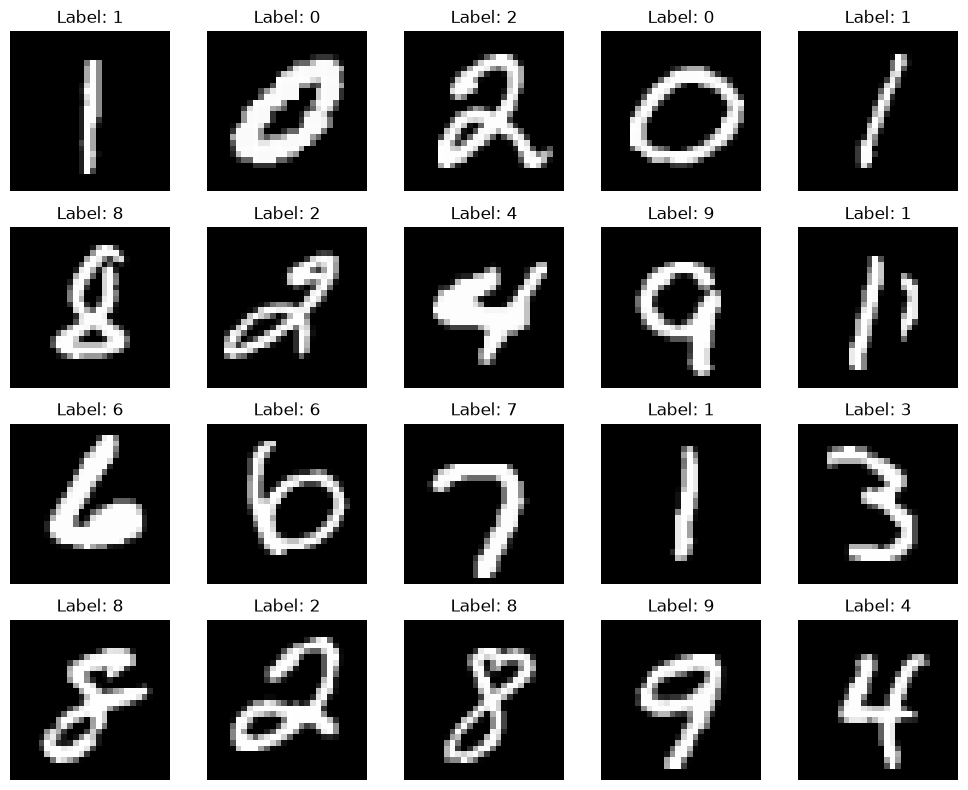

In [3]:
# Pick 20 random indices from the training set, so we see a different batch each run
random_indices = np.random.choice(len(train_dataset), size=20, replace=False)

plt.figure(figsize=(10, 8))

for plot_position, index in enumerate(random_indices):
    image, label = train_dataset[index]
    plt.subplot(4, 5, plot_position + 1)
    # image is a (1, 28, 28) tensor; .squeeze() drops the channel dimension for plotting,
    # and matplotlib needs a plain numpy array rather than a PyTorch tensor
    plt.imshow(image.squeeze().numpy(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Prepare the data (batching)

Pixel values are already normalised (Step 2), so the only preparation left is **batching**:
grouping images together so the model can process several at once instead of one at a time,
which is both faster and helps training be more stable.

In Keras, `model.fit()` handles batching for you automatically behind the scenes. In PyTorch,
you do this explicitly with a `DataLoader`, which wraps a dataset and hands out batches of a
size you choose:

- `batch_size=32` means each batch contains 32 images
- `shuffle=True` for training means the order is randomised each epoch, which helps the model
  learn general patterns rather than being influenced by the order images happen to appear in
- We don't need to shuffle the test set, since we're only ever reading from it, never learning
  from its order

In [4]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)} (of up to {BATCH_SIZE} images each)")
print(f"Testing batches: {len(test_loader)} (of up to {BATCH_SIZE} images each)")

Training batches: 1875 (of up to 32 images each)
Testing batches: 313 (of up to 32 images each)


## Step 5: Build the model

In PyTorch, you define a model as a Python class that inherits from `nn.Module`. There are two
parts:
- `__init__`: declare the layers you'll use (this is where the model's learnable weights live)
- `forward`: define the actual order data flows through those layers when the model is used

This is a bit more code than Keras' `Sequential([...])` list, but it's the same idea — and gives
you the flexibility to write more complex data flow later (branches, loops, skip connections)
that a simple stacked list can't express.

Our architecture mirrors the TensorFlow notebook's model exactly:
1. **Flatten**: turns each 28x28 image into a flat list of 784 numbers
2. **Linear(784, 128)**: PyTorch's name for what Keras calls `Dense` — every one of its 128
   neurons looks at all 784 input numbers
3. **ReLU**: the same "turn negatives into 0" activation as before — in PyTorch it's its own
   layer, rather than an `activation=` argument on the Linear layer
4. **Dropout(0.2)**: randomly disables 20% of neurons during training, to help prevent overfitting
5. **Linear(128, 10)**: the output layer, one number per digit (0-9)

### An important difference: no softmax here

Notice there's **no softmax activation** on the output layer, unlike the TensorFlow model. This
model outputs 10 raw, unbounded numbers called **logits** rather than probabilities. That's not
an oversight — it's standard PyTorch practice, and Step 6 explains exactly why.

In [5]:
class HandwrittenDigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.output = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output(x)   # raw logits - see Step 6 for why we don't apply softmax here
        return x


model = HandwrittenDigitClassifier()
print(model)

# Unlike model.summary() in Keras, PyTorch has no built-in summary table -
# we can total up the learnable parameters ourselves
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

HandwrittenDigitClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 101,770
Trainable parameters: 101,770


### What to expect

You should see **101,770 total parameters** — exactly the same number as the TensorFlow model,
since it's the same architecture (784 x 128 + 128 biases, then 128 x 10 + 10 biases). The layer
list above is PyTorch's plain-text equivalent of Keras' `model.summary()` table; it's less
formatted, but shows the same information: every layer we defined, in order.

## Step 6: Define the loss function and optimizer

There's no single `.compile()` step in PyTorch — instead, we create the loss function and
optimizer as their own separate objects, which we'll use ourselves in the training loop we write
in Step 7. Conceptually, this configures exactly the same two things Step 6 of the TensorFlow
notebook did:

- **Loss function** (`nn.CrossEntropyLoss()`): scores how wrong a prediction was. This is
  PyTorch's equivalent of Keras' `sparse_categorical_crossentropy` — and it's the reason our
  model outputs raw logits instead of probabilities. `CrossEntropyLoss` **applies softmax
  internally** as part of its calculation, combined with the loss formula, in a single numerically
  stable step. Applying softmax ourselves first and then feeding *that* into this loss function
  would be redundant, and is a common PyTorch beginner mistake to watch out for.
- **Optimizer** (`torch.optim.Adam(model.parameters(), lr=0.001)`): the same Adam algorithm used
  in the TensorFlow notebook. `model.parameters()` tells it exactly which numbers it's allowed to
  adjust (every weight and bias in our model), and `lr` (the **learning rate**) controls how big a
  step it takes each time it updates them — 0.001 is Adam's typical default, and a good starting
  point for problems like this one.

Notice there's no `metrics=["accuracy"]` here either — PyTorch doesn't track metrics for you
automatically. We'll calculate accuracy ourselves, directly in the training and evaluation loops.

In [6]:
criterion = nn.CrossEntropyLoss()   # "criterion" is PyTorch's conventional name for the loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Step 7: Train the model

This is the biggest difference from the Keras version: instead of calling one `model.fit(...)`
line, we write the training loop ourselves. It looks like more code, but it's really the same
four steps repeated over and over, which map directly onto ideas from Step 6:

1. **Forward pass**: show the model a batch of images and get its (currently not-very-good) predictions
2. **Loss**: use `criterion` to measure how wrong those predictions were
3. **Backward pass**: call `.backward()`, which uses **autograd** (PyTorch's automatic
   differentiation engine) to work out exactly how much each individual weight in the model
   contributed to that error
4. **Optimizer step**: call `optimizer.step()` to actually nudge every weight in the direction
   that should reduce the error next time

One easy-to-forget detail: gradients **accumulate** by default in PyTorch rather than being reset
automatically, so we have to explicitly clear them with `optimizer.zero_grad()` at the start of
every batch — otherwise each new batch's gradients would just pile on top of the last one's.

We also call `model.train()` before the loop. This puts the model in "training mode", which
matters specifically because of Dropout (Step 5) — it should randomly disable neurons *only*
during training, not later when we evaluate or make real predictions.

An **epoch** still means one full pass through all 60,000 training images, and we'll train for
5 of them, matching the TensorFlow notebook.

**Note:** the cell below prints its own progress per epoch (there's no automatic progress bar
like Keras provides) — wait for "Training complete!" before running the next cell.

In [7]:
# Train on a GPU automatically if one's available, otherwise fall back to the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

EPOCHS = 5

print("\nTraining the model - please wait for this to finish before running the next cell...\n")

for epoch in range(EPOCHS):
    model.train()  # switch to training mode (this activates Dropout)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()               # clear gradients left over from the last batch
        outputs = model(images)             # forward pass: get the model's current predictions
        loss = criterion(outputs, labels)   # measure how wrong those predictions were
        loss.backward()                     # backward pass: work out how to adjust each weight
        optimizer.step()                    # actually apply that adjustment

        running_loss += loss.item() * images.size(0)
        predicted_digits = outputs.argmax(dim=1)          # the highest-scoring logit wins
        correct += (predicted_digits == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    print(f"Epoch {epoch + 1}/{EPOCHS} - loss: {epoch_loss:.4f} - accuracy: {epoch_accuracy:.4f}")

print("\nTraining complete! You can now move on to the next cell.")

Using device: cpu

Training the model - please wait for this to finish before running the next cell...

Epoch 1/5 - loss: 0.3275 - accuracy: 0.9094
Epoch 2/5 - loss: 0.1579 - accuracy: 0.9536
Epoch 3/5 - loss: 0.1152 - accuracy: 0.9653
Epoch 4/5 - loss: 0.0956 - accuracy: 0.9710
Epoch 5/5 - loss: 0.0816 - accuracy: 0.9743

Training complete! You can now move on to the next cell.


## Step 8: Evaluate the model

Just like Step 8 of the TensorFlow notebook, we check performance on the **test set** — 10,000
images the model never saw during training — since that's what tells us how well it generalises.

Two PyTorch-specific details to notice in the code:
- `model.eval()` switches off training-only behaviour, most importantly Dropout — during
  evaluation we want to use the *whole* network, not a randomly thinned-out version of it
- `with torch.no_grad():` tells PyTorch not to bother tracking gradients for anything inside this
  block. We're not training here, so there's no need to prepare for a `.backward()` call — skipping
  it saves memory and makes evaluation noticeably faster

### Understanding the test accuracy

You should see accuracy somewhere around **97-98%**, same as the TensorFlow version — which makes
sense, since it's the same architecture trained on the same data. If your result seems low, some
PyTorch-specific things worth checking, in addition to the general causes from the TensorFlow
notebook (too few epochs, an overly simple model):

- **Forgot `optimizer.zero_grad()`** in the training loop: gradients pile up across batches instead
  of being freshly calculated each time, badly confusing the optimizer
- **Forgot `model.eval()` before evaluating**: Dropout would still be randomly disabling neurons,
  making the model perform worse than it actually would in normal use
- **Forgot `model.train()` before the *next* round of training**: once you call `.eval()`, the
  model stays in evaluation mode until you explicitly switch it back
- **Data or model on different devices**: if you have a GPU and only moved one of `model` or
  `images` to it with `.to(device)`, PyTorch will raise an error rather than silently getting it
  wrong — but it's a common early mistake worth knowing about

In [8]:
model.eval()  # switch to evaluation mode (disables Dropout)

correct = 0
total = 0
running_test_loss = 0.0

with torch.no_grad():  # we're not training, so there's no need to track gradients here
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_test_loss += loss.item() * images.size(0)
        predicted_digits = outputs.argmax(dim=1)
        correct += (predicted_digits == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
test_loss = running_test_loss / total
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Test accuracy: 0.9753 (97.53%)


## Step 9: Make predictions

Let's generate predictions for the whole test set at once, and see exactly what's involved in
turning the model's raw output into a human-readable answer.

### From logits to probabilities

Remember from Step 5 that our model outputs 10 raw **logits** per image, not probabilities. To
get something as easy to interpret as the TensorFlow model's softmax output, we apply
`torch.softmax(logits, dim=1)` ourselves — `dim=1` tells it to turn each *row* (one image's 10
logits) into a probability distribution that sums to 1, rather than doing it down columns.

Once we have probabilities, finding the answer works exactly like the TensorFlow notebook:
`argmax` finds the *position* of the largest probability, which is the model's predicted digit.

In [9]:
# Load the entire test set as a single batch, so we can compute predictions for everything at once
full_test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
x_test_tensor, y_test_tensor = next(iter(full_test_loader))

model.eval()
with torch.no_grad():
    logits = model(x_test_tensor.to(device))
    predictions = torch.softmax(logits, dim=1).cpu().numpy()  # convert logits to probabilities

# Plain numpy versions, handy for plotting and indexing later in this notebook
x_test_images = x_test_tensor.squeeze(1).numpy()   # drop the channel dimension: (10000, 28, 28)
y_test = y_test_tensor.numpy()

print("Predicted probabilities for the first test image:")
print(np.round(predictions[0], 2))

predicted_digit = np.argmax(predictions[0])
print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[0])

Predicted probabilities for the first test image:
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Predicted digit: 7
Actual digit: 7


### Seeing the full probability array, for several examples

Just like the TensorFlow notebook, let's plot the probability array as a bar chart next to the
image that produced it, for a few random examples. The tallest bar is the model's answer — but
how tall it is, and whether any other bars come close, shows you its confidence, not just its
final guess.

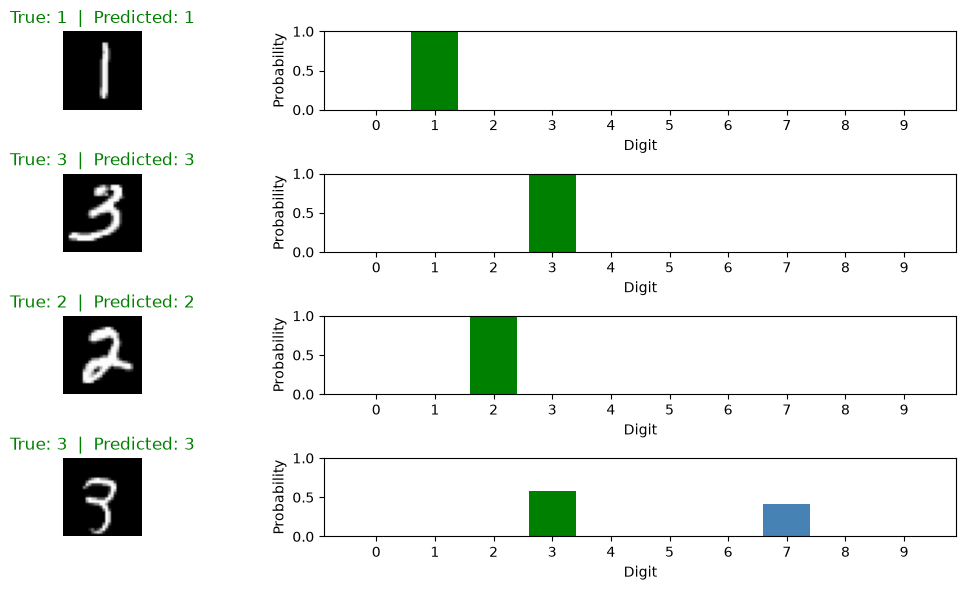

In [10]:
# Pick a few random test images to inspect closely
example_indices = np.random.choice(len(x_test_images), size=4, replace=False)

plt.figure(figsize=(12, 6))

for row, index in enumerate(example_indices):
    # Left column: the actual image
    plt.subplot(4, 2, row * 2 + 1)
    plt.imshow(x_test_images[index], cmap="gray")
    predicted_digit = np.argmax(predictions[index])
    color = "green" if predicted_digit == y_test[index] else "red"
    plt.title(f"True: {y_test[index]}  |  Predicted: {predicted_digit}", color=color)
    plt.axis("off")

    # Right column: a bar chart of all 10 probabilities for this image
    plt.subplot(4, 2, row * 2 + 2)
    bar_colors = ["green" if digit == y_test[index] else "steelblue" for digit in range(10)]
    plt.bar(range(10), predictions[index], color=bar_colors)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.xlabel("Digit")

plt.tight_layout()
plt.show()

## Step 10: Visualise predictions

Let's look at several test images side by side with the model's predicted digit and the true
digit. Correct predictions are shown in green, wrong ones in red.

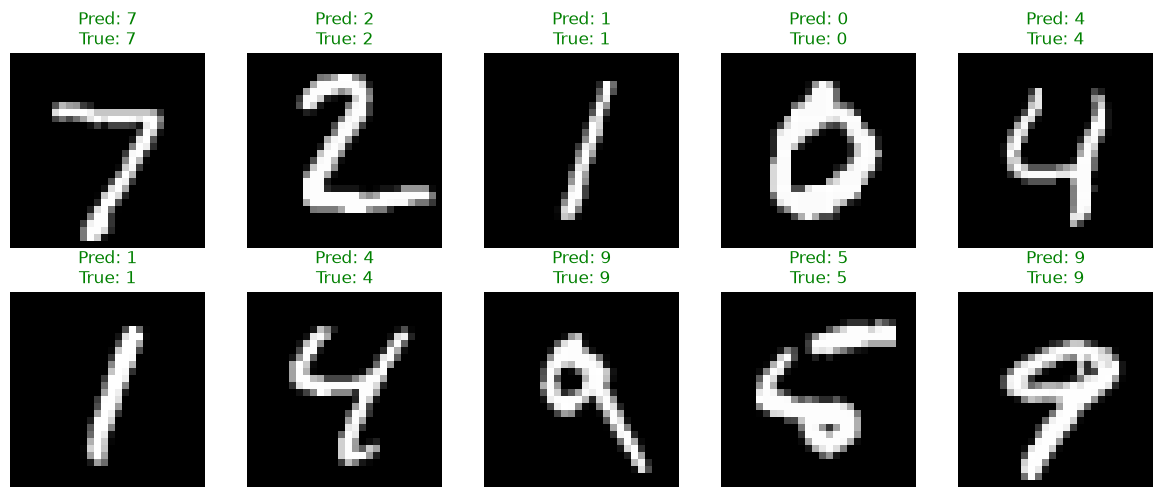

In [11]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_images[i], cmap="gray")
    plt.axis("off")

    predicted_digit = np.argmax(predictions[i])
    actual_digit = y_test[i]

    color = "green" if predicted_digit == actual_digit else "red"
    plt.title(f"Pred: {predicted_digit}\nTrue: {actual_digit}", color=color)

plt.tight_layout()
plt.show()

## Step 11: Draw your own digit and test the model!

The real test of our model is whether it can recognise *your* handwriting, not just MNIST's.

Below is the same kind of drawing canvas as the TensorFlow notebook. Draw a single digit (0-9)
with your mouse, click **Predict**, then confirm whether it was correct:
- If it was, great — nothing more to do.
- If it wasn't, pick the correct digit and click **Teach the model**. This runs a few quick
  training steps on your drawing — the same online learning idea as before, just written out
  manually using the same `zero_grad` / forward / `backward` / `step` pattern from Step 7.

A few tips for best results:
- Draw a large digit that fills most of the canvas (MNIST digits are big and centred)
- Use a single, fairly thick stroke
- The model was only ever trained on MNIST's style of digit — don't be surprised if it gets
  confused by unusual handwriting!

### Step 11a: Set up the drawing canvas

This part is identical to the TensorFlow notebook — the canvas itself has nothing to do with
which machine learning framework we're using.

In [12]:
# ipycanvas gives us a drawable canvas widget; ipywidgets gives us buttons and layout
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

# The canvas is a bit larger than the 28x28 MNIST image, but small enough that the
# whole drawing area fits on screen without needing to scroll
CANVAS_SIZE = 200

# sync_image_data=True lets us read back what was drawn, from Python
canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)

# MNIST digits are white strokes on a black background, so we draw the same way
canvas.fill_style = "black"
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
canvas.stroke_style = "white"
canvas.line_width = 14
canvas.line_cap = "round"

# Keep track of whether the mouse button is currently held down
is_drawing = False

def start_drawing(x, y):
    global is_drawing
    is_drawing = True
    canvas.begin_path()
    canvas.move_to(x, y)

def draw_line(x, y):
    if is_drawing:
        canvas.line_to(x, y)
        canvas.stroke()

def stop_drawing(x, y):
    global is_drawing
    is_drawing = False

canvas.on_mouse_down(start_drawing)
canvas.on_mouse_move(draw_line)
canvas.on_mouse_up(stop_drawing)

### Step 11b: Predict, confirm, and learn from corrections

This is where the PyTorch-specific code lives: converting the drawing into a tensor, running it
through the model in evaluation mode for a prediction, and - if you correct it - running a few
manual training steps to update the model's weights.

In [13]:
def preprocess_drawing(canvas):
    """Turn what's drawn on the canvas into a 28x28 image the model can understand."""

    # Read the canvas as an array of pixels (each pixel has Red, Green, Blue, Alpha)
    image_data = canvas.get_image_data()

    # Our drawing is white-on-black, so the Red channel alone tells us brightness (0-255)
    brightness = image_data[:, :, 0]

    # Find the box that tightly contains everything we've drawn
    drawn_rows = np.any(brightness > 0, axis=1)
    drawn_cols = np.any(brightness > 0, axis=0)

    if not drawn_rows.any():
        return None  # Nothing has been drawn yet

    top, bottom = np.where(drawn_rows)[0][[0, -1]]
    left, right = np.where(drawn_cols)[0][[0, -1]]

    # Crop to the drawn digit, then centre it in a 28x28 frame
    # (MNIST digits are centred with some empty space around them)
    digit = Image.fromarray(brightness[top:bottom + 1, left:right + 1].astype("uint8"))
    digit.thumbnail((20, 20))  # Shrink to fit in a 20x20 box, keeping its proportions

    canvas_28 = Image.new("L", (28, 28), color=0)  # Blank 28x28 black image
    paste_x = (28 - digit.width) // 2
    paste_y = (28 - digit.height) // 2
    canvas_28.paste(digit, (paste_x, paste_y))  # Centre the digit in the middle

    # Scale pixel values to 0-1, matching what ToTensor() gave us back in Step 2
    return np.array(canvas_28) / 255.0


# These remember the most recent prediction, so the feedback buttons below can use them
last_drawn_image = None
last_predicted_digit = None

result_output = widgets.Output()    # Shows the drawn digit and the model's prediction
feedback_output = widgets.Output()  # Shows the "was this correct?" controls


def show_feedback_prompt():
    """Ask the user whether the last prediction was correct."""
    feedback_output.clear_output()
    with feedback_output:
        print("Was that correct?")
        display(widgets.HBox([correct_button, incorrect_button]))


def on_predict_clicked(button):
    global last_drawn_image, last_predicted_digit

    result_output.clear_output(wait=True)
    with result_output:
        processed_image = preprocess_drawing(canvas)
        if processed_image is None:
            print("Draw a digit first!")
            feedback_output.clear_output()
            return

        # Turn the numpy image into a tensor shaped like the model expects: (batch, channel, H, W)
        image_tensor = torch.tensor(processed_image, dtype=torch.float32).reshape(1, 1, 28, 28)

        model.eval()
        with torch.no_grad():
            logits = model(image_tensor.to(device))
            probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]

        predicted_digit = np.argmax(probabilities)
        confidence = np.max(probabilities) * 100

        # Remember this prediction so the feedback buttons know what they're correcting
        last_drawn_image = processed_image
        last_predicted_digit = predicted_digit

        # Show exactly what the model saw, next to its answer
        plt.figure(figsize=(2.2, 2.2))
        plt.imshow(processed_image, cmap="gray")
        plt.title(f"Predicted: {predicted_digit} ({confidence:.1f}%)", fontsize=10)
        plt.axis("off")
        plt.show()

    show_feedback_prompt()


def on_clear_clicked(button):
    global last_drawn_image, last_predicted_digit
    canvas.fill_style = "black"
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    last_drawn_image = None
    last_predicted_digit = None
    result_output.clear_output()
    feedback_output.clear_output()


def on_correct_clicked(button):
    feedback_output.clear_output()
    with feedback_output:
        print("Great! Glad it got that one right.")


def on_incorrect_clicked(button):
    # Let the user pick the real digit, then teach the model with it
    digit_picker = widgets.Dropdown(options=list(range(10)), description="Actual digit:")
    teach_button = widgets.Button(description="Teach the model", button_style="info")

    def on_teach_clicked(button):
        # A few manual training steps on this one example, using the correct label - the same
        # zero_grad / forward / loss / backward / step pattern from Step 7, just repeated a
        # handful of times by hand instead of by a DataLoader loop. This is a toy version of
        # "online learning" - nudging the model's weights with one new example, rather than
        # retraining from scratch. Doing this too often on too few examples can make the model
        # overfit to your handwriting and forget general patterns it learned from MNIST - so
        # treat it as a fun demo, not a real training strategy.
        image_tensor = torch.tensor(last_drawn_image, dtype=torch.float32).reshape(1, 1, 28, 28)
        correct_label = torch.tensor([digit_picker.value])

        model.train()
        for _ in range(3):
            optimizer.zero_grad()
            logits = model(image_tensor.to(device))
            loss = criterion(logits, correct_label.to(device))
            loss.backward()
            optimizer.step()
        model.eval()

        feedback_output.clear_output()
        with feedback_output:
            print(f"Thanks! The model just learned this drawing is a {digit_picker.value}.")

    teach_button.on_click(on_teach_clicked)

    feedback_output.clear_output()
    with feedback_output:
        print("Sorry about that! What digit did you actually draw?")
        display(widgets.HBox([digit_picker, teach_button]))


correct_button = widgets.Button(description="Yes, correct", button_style="success")
incorrect_button = widgets.Button(description="No, wrong", button_style="danger")
correct_button.on_click(on_correct_clicked)
incorrect_button.on_click(on_incorrect_clicked)

predict_button = widgets.Button(description="Predict", button_style="success")
clear_button = widgets.Button(description="Clear", button_style="warning")
predict_button.on_click(on_predict_clicked)
clear_button.on_click(on_clear_clicked)

# Show the canvas, the buttons, the prediction, and the feedback controls together
display(canvas, widgets.HBox([predict_button, clear_button]), result_output, feedback_output)

Canvas(height=200, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\xc8\x00\x00\x00\xc8\x08\x06\x0…

Output()

Output()

## Step 12: Save the trained model (optional)

Once we're happy with our model, we can save it so we can reuse it later without retraining.

### What does a saved PyTorch model actually contain?

This is a genuinely important difference from the TensorFlow notebook. Keras' `.keras` file is
**self-describing** — it bundles the architecture, the weights, and the training configuration
all together, so loading it back is a single line that gives you a fully working model.

The recommended way to save a PyTorch model, by contrast, saves **only the learned weights** —
called the model's `state_dict` (short for "state dictionary"): a plain Python dictionary mapping
each layer's name to its current tensor of numbers. It does **not** include the model's
architecture. This means loading it back is a two-step process: first recreate an *empty* model
using the same class definition from Step 5, then load the saved numbers into it:

```python
model = HandwrittenDigitClassifier()  # 1. rebuild the (untrained) architecture
model.load_state_dict(torch.load("handwritten_digit_model_pytorch.pt"))  # 2. load the learned weights in
model.eval()
```

Why does PyTorch work this way? Saving only the weights keeps the file smaller and avoids tying
it to exact library/code versions the way saving a whole Python object can. The trade-off is that
*you* are responsible for keeping the model class definition around — the file alone isn't enough
to reconstruct the network, unlike a `.keras` file.

In [ ]:
torch.save(model.state_dict(), "handwritten_digit_model_pytorch.pt")
print("Model weights saved as handwritten_digit_model_pytorch.pt")

# To load them again later, you would need the HandwrittenDigitClassifier class defined
# (Step 5), then:
# model = HandwrittenDigitClassifier()
# model.load_state_dict(torch.load("handwritten_digit_model_pytorch.pt"))
# model.eval()

## Summary

This notebook walked through the same machine learning workflow as the TensorFlow notebook, but
written the PyTorch way:

1. **Get labelled data** — MNIST, loaded and automatically normalised by `ToTensor()` (Step 2)
2. **Explore it** — looking at real examples before doing anything else (Step 3)
3. **Batch it** — wrapping the dataset in `DataLoader`s, since PyTorch doesn't batch data for you automatically (Step 4)
4. **Design a model** — a class-based `nn.Module`, ending in raw logits rather than softmax probabilities (Step 5)
5. **Configure training** — a separate loss function and optimizer, rather than one `.compile()` call (Step 6)
6. **Train** — a training loop we wrote ourselves: forward pass, loss, backward pass, optimizer step (Step 7)
7. **Evaluate honestly** — checking accuracy on unseen test data, in evaluation mode with gradients switched off (Step 8)
8. **Use the model** — converting logits to probabilities and inspecting them (Step 9-10)
9. **Test it in the real world** — the drawing canvas, plus manual online learning steps to correct mistakes (Step 11)
10. **Persist the result** — saving the model's `state_dict` (Step 12)

### Key terms recap

| Term | What it means |
|---|---|
| **Tensor** | PyTorch's version of a numpy array - a grid of numbers, with the extra ability to track how it was computed for training |
| **Logits** | The raw, unbounded output numbers from a model's final layer, before converting them into probabilities |
| **Autograd** | PyTorch's automatic differentiation engine - it's what makes `.backward()` able to work out how every weight contributed to the loss |
| **Forward pass** | Running data through the model to get a prediction |
| **Backward pass** | Working backwards from the loss to work out how each weight should change |
| **state_dict** | A dictionary of a model's learned weights, without its architecture - PyTorch's standard way to save/load models |
| **DataLoader** | An object that hands out a dataset in shuffled batches, so a training loop can process it a chunk at a time |

### How this compares to Keras, at a glance

| Concept | Keras (TensorFlow notebook) | PyTorch (this notebook) |
|---|---|---|
| Defining a model | `Sequential([...])` list of layers | A class with `__init__` (layers) and `forward` (data flow) |
| Final layer | `Dense(10, activation="softmax")` - outputs probabilities | `Linear(128, 10)` - outputs raw logits |
| Normalising pixels | Manual: `x_train = x_train / 255.0` | Automatic: built into `transforms.ToTensor()` |
| Configuring training | One `model.compile(...)` call | Separate `criterion` and `optimizer` objects |
| Batching data | Handled automatically inside `model.fit()` | Explicit `DataLoader` objects |
| Training | `model.fit(x_train, y_train, epochs=5)` | A `for` loop you write yourself, calling `zero_grad()` / `backward()` / `step()` |
| Tracking accuracy while training | Automatic, via `metrics=["accuracy"]` | Calculated by hand inside the training loop |
| Evaluating | `model.evaluate(x_test, y_test)` | A loop over `test_loader`, wrapped in `model.eval()` and `torch.no_grad()` |
| Saving | One self-describing `.keras` file (architecture + weights) | A `state_dict` of just the weights - you keep the class definition separately |

Neither approach is "better" outright — Keras optimises for getting something working quickly
with sensible defaults; PyTorch optimises for visibility and control over exactly what's
happening at each step. Plenty of real-world projects use PyTorch specifically *because* that
extra visibility makes debugging and customising unusual training setups much easier.

### Ideas to try next

- Train for more epochs, and watch the printed loss/accuracy to see how it changes
- Try a different optimizer (e.g. `torch.optim.SGD`) or learning rate, and compare results
- See how the model handles messy or unusually-shaped handwriting on the drawing canvas, and use the "teach the model" feature to correct it live
- Curious what `.backward()` actually calculates? See the **Bonus: Watch backpropagation happen** section below, which inspects real gradient tensors and checks them against a hand-worked calculus example
- Try a **Convolutional Neural Network (CNN)** instead — see the Bonus section below

## Bonus: Watch backpropagation happen

Step 7 already called `loss.backward()` explicitly, so in a sense we've been doing
**backpropagation** in plain sight this whole notebook — unlike Keras, PyTorch never hides it
inside a single `.fit()` call. But we never actually *looked* at what `.backward()` produces.
This bonus section does exactly that: it inspects the real gradient tensors it calculates, and
checks them against a hand-worked calculus example to prove nothing magical is going on.

### The core idea, before any neural network is involved

Backpropagation is really just the **chain rule** from calculus, applied automatically. Let's see
it on the simplest possible example first: one input number, one weight, one output — no layers,
no images, nothing hidden. This is small enough to check PyTorch's answer by hand.

In [ ]:
# The simplest possible "model": one weight, predicting prediction = w * x
x = torch.tensor(3.0)                        # a fixed input
target = torch.tensor(10.0)                  # what we wish the prediction was
w = torch.tensor(2.0, requires_grad=True)    # our one and only "weight" -
                                              # requires_grad=True tells autograd to track it

prediction = w * x                     # forward pass
loss = (prediction - target) ** 2      # squared error: how wrong were we?

# This is the backward pass: autograd replays everything above, backwards, applying
# the chain rule to work out d(loss)/dw - how much a tiny nudge to w would change the loss
loss.backward()

print(f"prediction = w * x = {w.item()} * {x.item()} = {prediction.item()}")
print(f"loss = (prediction - target)^2 = ({prediction.item()} - {target.item()})^2 = {loss.item()}")
print(f"\nGradient PyTorch calculated: {w.grad.item()}")

# Let's check that by hand, using the chain rule ourselves:
# loss = (w*x - target)^2
# d(loss)/dw = 2 * (w*x - target) * x
manual_gradient = 2 * (w.item() * x.item() - target.item()) * x.item()
print(f"Gradient calculated by hand: {manual_gradient}")

Both numbers should match exactly. PyTorch didn't guess, look anything up, or approximate — it
mechanically applied the same chain rule you'd use with pen and paper, just automatically. This
is exactly what happened, at much larger scale, every time `loss.backward()` ran in Step 7.

### Now let's actually look inside the real model's gradients

Our model has 101,770 weights instead of 1, chained through four layers instead of one
multiplication — but the mechanism is identical. Let's grab a real batch, call `.backward()`
the same way Step 7 does, and this time actually inspect what it calculated instead of
immediately consuming it in a training loop.

In [ ]:
# Grab one real batch from the training data
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

optimizer.zero_grad()  # clear any leftover gradients from earlier in the notebook

# Before the backward pass, there are no gradients yet - nothing has been calculated
print("model.hidden.weight.grad BEFORE backward():", model.hidden.weight.grad)

outputs = model(images)              # forward pass
loss = criterion(outputs, labels)    # measure how wrong the predictions were
print(f"\nLoss for this batch: {loss.item():.4f}")

# The backward pass: autograd walks backwards through every operation used above,
# applying the chain rule at each one, until it has a gradient for every trainable weight
loss.backward()

# Now every parameter that took part in the forward pass has a populated .grad tensor
first_layer_gradients = model.hidden.weight.grad

print(f"\nFirst layer weight matrix shape: {model.hidden.weight.shape}")   # (128, 784): (neurons, pixels)
print(f"Matching gradient shape:         {first_layer_gradients.shape}")

# Pixel 400 sits roughly in the middle of the 28x28 image, where digit strokes actually
# appear. PyTorch's Linear weight is shaped (out_features, in_features) - the opposite of
# Keras' Dense kernel - so input pixels are the SECOND dimension here, not the first
print(f"\nA few example gradient values (5 neurons' connections to pixel index 400):\n{first_layer_gradients[:5, 400]}")

### Reading the gradients

Notice `.grad` was `None` before `backward()` ran, then became a real tensor - the same shape as
the weight tensor it belongs to - afterwards. Every one of those numbers tells that specific
weight two things:

- **Sign**: whether *increasing* that weight would increase or decrease the loss
- **Magnitude**: how much difference that weight makes right now — near 0 means "barely matters
  at the moment", larger means "this one has a real effect on the loss"

**Try it yourself:** change the pixel index above from `400` to `0` and re-run the cell. You'll
get back exactly zero for every value — not "very small", but *exactly* 0. That's not a bug:
pixel 0 is a corner of the image, and MNIST digits are always centred with black borders, so
that pixel is 0 in essentially every training image. A weight that only ever multiplies against
0 can never affect the loss, so its gradient is always exactly 0 too.

`optimizer.step()` (Step 7) uses exactly this information, for all 101,770 weights at once, to
decide how to adjust each one. Let's prove it by applying one real update and watching a weight
change.

In [ ]:
# Save the model's current weights, so we can restore them afterwards - this is just a
# demonstration, and we don't want it to affect the model used in the rest of the notebook
import copy
original_state = copy.deepcopy(model.state_dict())

# Same neuron-0-to-pixel-400 connection as above, which we know has a real (non-zero)
# gradient - remember pixels are the SECOND index for this weight tensor (see note above)
weight_before = model.hidden.weight[0, 400].item()

optimizer.step()   # apply one real update, using the gradients we just calculated

weight_after = model.hidden.weight[0, 400].item()

print(f"Weight value before this update: {weight_before:.8f}")
print(f"Weight value after this update:  {weight_after:.8f}")
print(f"Change:                          {weight_after - weight_before:.8f}")

# Restore the original weights, undoing our one manual update
model.load_state_dict(original_state)
optimizer.zero_grad()
print("\n(Model weights restored to their trained state - this was just a demonstration.)")

## Bonus: Try a CNN yourself

### Where in the code above you'd need to change things

If you wanted to convert the whole notebook above to use a CNN instead of our simple Linear-layer
network, here's exactly what would need to change:

- **Step 2 (Load the data)**: no changes needed at all! This is a nice contrast with the
  TensorFlow notebook, where we had to manually add a channel dimension for the CNN bonus.
  `ToTensor()` already gives us images shaped `(1, 28, 28)` - one channel, 28x28 pixels - which is
  exactly the shape `Conv2d` layers expect. The Linear-based model only worked with this same data
  because `nn.Flatten()` collapsed it down to a flat list first.

- **Step 5 (Build the model)**: replace the flatten-first architecture with convolutional layers
  that keep the image in its 2D grid shape, only flattening near the end:
  ```python
  class CNNClassifier(nn.Module):
      def __init__(self):
          super().__init__()
          self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
          self.pool = nn.MaxPool2d(kernel_size=2)
          self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
          self.flatten = nn.Flatten()
          self.fc1 = nn.Linear(64 * 5 * 5, 64)   # see note below on this number
          self.relu = nn.ReLU()
          self.dropout = nn.Dropout(0.3)
          self.fc2 = nn.Linear(64, 10)

      def forward(self, x):
          x = self.pool(self.relu(self.conv1(x)))
          x = self.pool(self.relu(self.conv2(x)))
          x = self.flatten(x)
          x = self.relu(self.fc1(x))
          x = self.dropout(x)
          x = self.fc2(x)
          return x
  ```
  Unlike Keras, PyTorch's `Conv2d`/`Linear` layers don't work out their input size automatically -
  you have to calculate it. Starting from a 28x28 image: a 3x3 convolution with no padding shrinks
  each side by 2 (28 to 26), then 2x2 pooling halves it (26 to 13); another 3x3 convolution takes
  13 to 11, and another 2x2 pooling takes 11 to 5 (rounding down). With 64 output channels from
  `conv2`, that's `64 x 5 x 5 = 1,600` numbers reaching the first `Linear` layer.

- **Steps 6-9 and 11-12**: no changes needed - the loss function, optimizer, training loop,
  evaluation loop, prediction code, and saving code all work exactly the same regardless of what's
  inside the model, since they only ever talk to `model(images)`, never to its internals.

### Try it here, without touching anything above

The cell below builds and trains a small CNN independently, so you can compare it against our
original model without affecting anything else. Feel free to tweak the number of filters, layers,
or epochs and re-run it.

**Note:** CNNs do more computation per image than our simple Linear-based network, so this cell
will generally take longer to train than Step 7 did.

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 5 * 5, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


cnn_model = CNNClassifier().to(device)
print(cnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

CNN_EPOCHS = 3
print(f"\nTraining the CNN - this takes longer than Step 7, please wait...\n")

for epoch in range(CNN_EPOCHS):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        cnn_optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch + 1}/{CNN_EPOCHS} - loss: {running_loss / total:.4f} - accuracy: {correct / total:.4f}")

print("\nTraining complete!")

# Evaluate, and compare directly against our original model's test accuracy from Step 8
cnn_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

cnn_test_accuracy = correct / total
print(f"\nCNN test accuracy:    {cnn_test_accuracy:.4f} ({cnn_test_accuracy * 100:.2f}%)")
print(f"Linear-model accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)  (from Step 8)")